In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import time

video_path = '/content/drive/MyDrive/CV_work/AI_응용_강의자료/data/newyork.mp4'

# flow 시각화 함수 정의
def drawFlow(img, flow, step=16):
    # Frameback Optical Flow 결과를 시각화 하는 함수
    # 특정 간격(step)마다 화살표를 그려 움직임 벡터를 표시
    h,w = img.shape[:2] #shape하면 h w c 나오니까 w까지만 가져옴
    # w,h = img.shape[:2:-1] 이것도 될걸?

    # 16픽셀 간격의 그리드를 가진 인덱스 구하기 (좌표: y,x)
    idx_y, idx_x = np.mgrid[step//2:h:step,step//2:w:step].astype(np.int32)
    # np.mgrid (mesh-grid)

    # 단순한 인덱싱은 아니고 원래 이렇게 쓰게 만들어졌음
    # mgrid안에는 뭐가 든거지? 인덱싱했으니까 이미 뭐가 들어있는거 아냐?
    # 얘 그거랑 되게 비슷한 친구네 자기 자리를 의미하는 np.indices.

    # y,x를 묶어서
    indices = np.stack((idx_x,idx_y), axis = -1).reshape(-1,2)
    # reshape으로 (N,2)형태로 만들었음. (x,y)로 넣었네요.

    # 화살표 색상 (녹색)

    arrow_color = (0,255,0)

    for x,y in indices:
        # 1. 그리드 인덱스 위치에 시작점 그리기
        cv2.circle(img, (x,y),1,arrow_color,-1)

        # 2. 각 그리드 인덱스에 해당하는 flow결과값을 -> 이동 거리로 사용
        # flow배열 (h,w,2) 형태고 (dx,dy)를 담고잇음
        # 모든 픽셀 자리에 dx,dy를 갖고있는 배열이야.
        # (dx,dy)는 float이니까 int로 바꿔줘야됨. 아마 np.int32겟죠?

        dx,dy = flow[y,x].astype(np.int32)
        # flow[y,x] 해당 위치의 움직임 array
        # dy : 아래가 +


        # 3. 각 그리드 인덱스 위치에서 이동한 거리만큼 선 그리기
        end_point = (x+dx, y+dy)

        # cv2.line() 대신 cv2.arrowedLine()사용
        cv2.arrowedLine(img,  (x,y), end_point, arrow_color, 1, cv2.LINE_AA, tipLength = 0.3)

        # cv2.LINE_AA : anti aliasing 부드러운선
        # tipLength = 0.3 : 화살 촉 크기 비율 30프로

prev = None

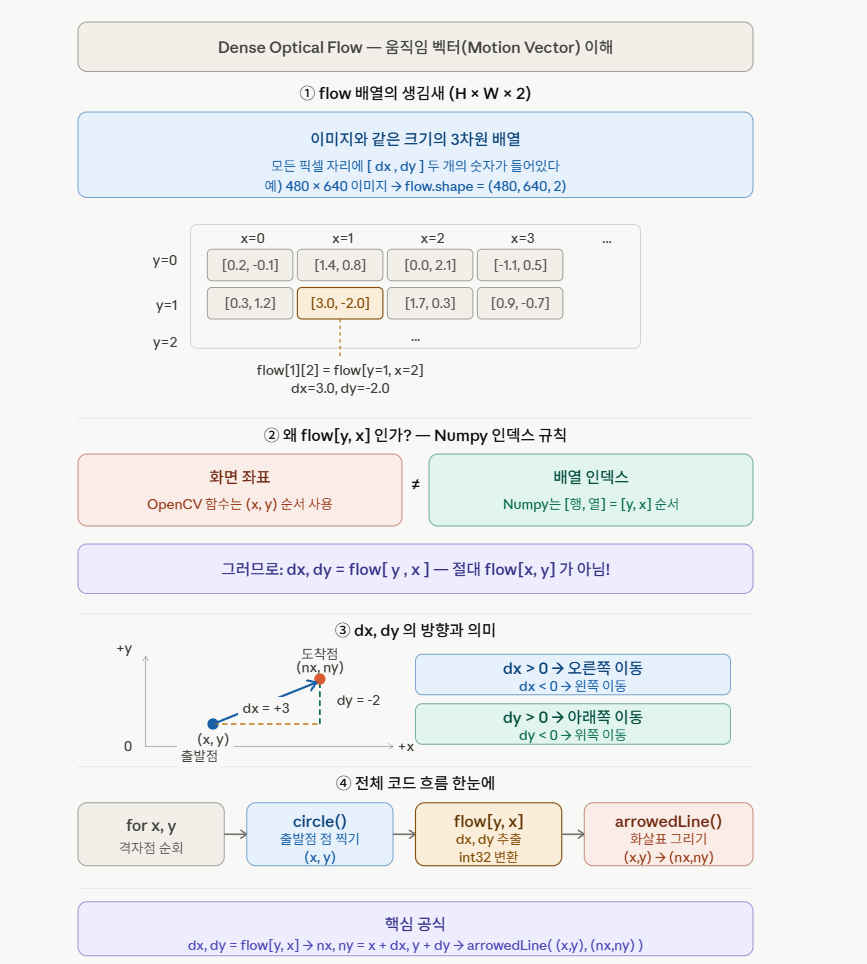

In [11]:
# 비디오 캡처 설정

cap = cv2.VideoCapture(video_path)

delay = int(1000/30)

if not cap.isOpened():
    print('Video open Failed!')
    exit()

frame_count = 0
MAX_FRAMES_TO_PROCESS = 150
DISPLAY_EVERY_N_FRAMES = 20

while cap.isOpened() and frame_count < MAX_FRAMES_TO_PROCESS:
    ret, frame = cap.read()
    if not ret:
        print('비디오 스트리밍 종료')
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 최초 프레임
    if prev is None:
        prev = gray
    else:
        # Farneback 옵티컬 플로우 -> 이게 Dence optical flow 계산
        # 모든 픽셀의 움직임 벡터 계산.
        # flow.shape : (H, W, 2)고 저 2는 (dx,dy)
        flow = cv2.calcOpticalFlowFarneback(prev,gray, None,
                                            0.5, # 이미지 피라미드 스케일(각 단계 에서 이미지 50%축소)
                                            3, # 피라미드 레벨 수 -> 3단계로 만든다.
                                            15, # 윈도우 크기 (평균 이동을 위한 이웃 픽셀 수)
                                            3, # 반복 횟수
                                            5, # 다항식 확장 크기 ( 픽셀 이웃을 다항식으로 근사)
                                            1.1, # 가우시안 시그마 값 .sigmaX
                                            cv2.OPTFLOW_FARNEBACK_GAUSSIAN)

        #이미지 피라미드는 원본에서 크기를 축소하면서 본다는 뜻?
        # 3단계에 50프로면
        # 원본 >> 50% >> 25% 이렇게 3단계야.
        # 큰 움직임도 파악 할 수 있음.

        # 윈도우 크기가 15라는건 15*15영역에서 계산한다는 뜻 -> 커널사이즈랑도 유사하네
        # 커지면 부드러워지면서 세밀함 감소, 작으면 노이즈 증가.

        # 다항식 확장 크기
        # 5 -> 5*5영역 (7이 일반적, 작으면 빠름)



        drawFlow(frame,flow) # 아까만든 화살표 만드는 함수

        prev = gray

    if frame_count % DISPLAY_EVERY_N_FRAMES ==0:
        print(f'Frame {frame_count} Farneback 광학 흐름 결과')
        cv2_imshow(frame)
        time.sleep(1)

    frame_count +=1

cap.release()




Output hidden; open in https://colab.research.google.com to view.

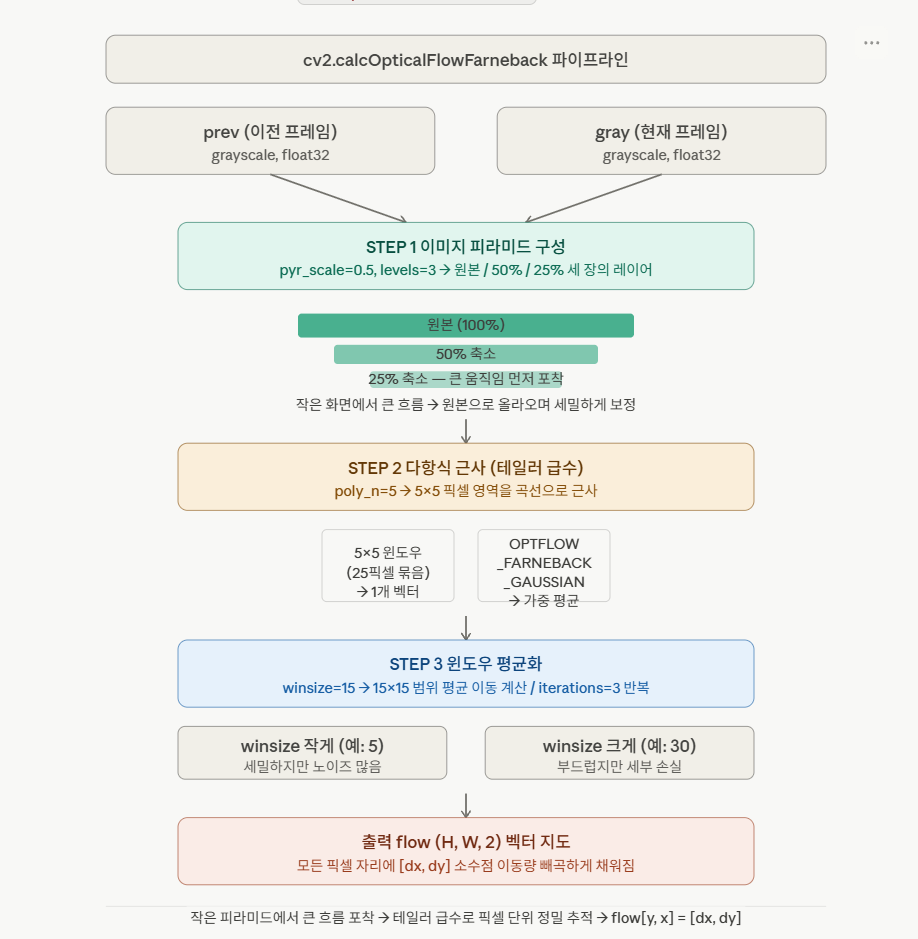

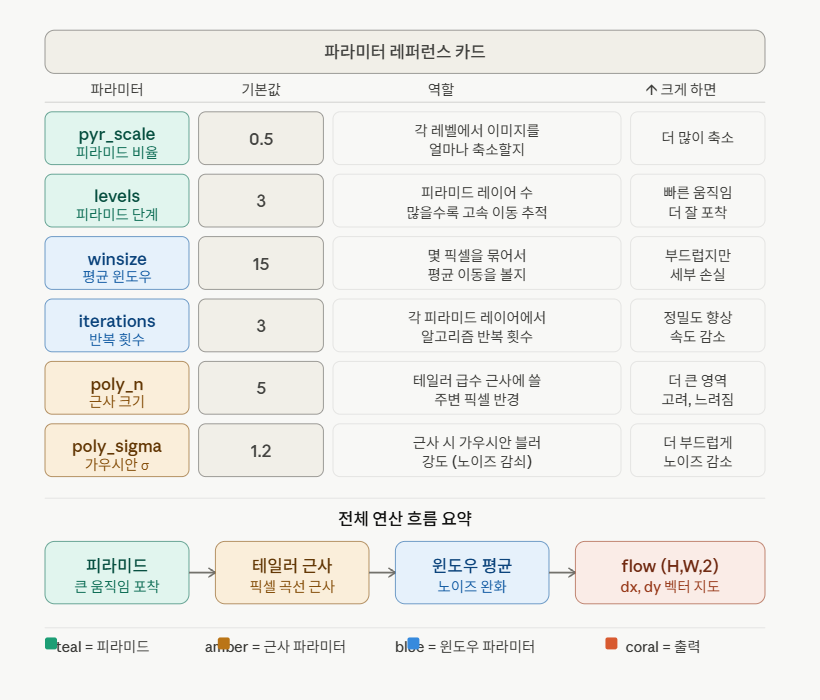

In [6]:

x_idx = [20,30,
         10]
y_idx = [40,50,60]

np.stack((x_idx,y_idx),axis=0) #행으로 붙인다. == 데이터 가장 바깥쪽
np.stack((x_idx,y_idx),axis=1) #열로 붙인다.
np.stack((x_idx,y_idx),axis=-1) #데이터 가장 안쪽을 건드린다. 즉, -1은 2차원에선 1이고, 3차원에선 2고


array([[20, 40],
       [30, 50],
       [10, 60]])